In [1]:
import sys
sys.path.append('../')
import numpy as np
import copy
from PIL import Image
import open3d as o3d
import matplotlib.pyplot as plt
from magpie_perception import pcd
from magpie_control import realsense_wrapper as real
import cv2
# from open3d.web_visualizer import draw

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
[Open3D INFO] Resetting default logger to print to terminal.


In [2]:
devices = real.poll_devices()
print(devices)
wrist = real.RealSense(fps=15, w=640, h=480, device_name="D405")
wrist.initConnection(device_serial=devices['D405'])
wkspc = real.RealSense(zMax=5, fps=6, w=640, h=480, device_name="D435")
wkspc.initConnection(device_serial=devices['D435'])

{'D435': '832412070344', 'D405': '126122270157'}
There are 2 available devices!
There are 2 available devices!


In [25]:
pcd_wrist, rgbd_wrist = wrist.getPCD()
pcd_wkspc, rgbd_wkspc = wkspc.getPCD()

img_wrist = np.array(rgbd_wrist.color)
img_wkspc = np.array(rgbd_wkspc.color)

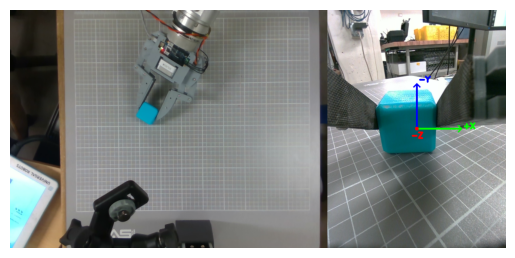

In [31]:
def label_wrist_image(wrist_img):
    '''
    labels wrist image with overlaid x,y,z axes in line with F/T sensor
    '''
    h, w, c = wrist_img.shape

    x_color = (0, 255, 0) # green
    y_color = (0, 0, 255) # blue
    z_color = (255, 0, 0) # red

    # Define axis line lengths (adjust as needed)
    axis_length = min(w, h) // 4

    # Calculate starting point for axes (center of the image)
    center_x, center_y = w // 2, h // 2

    # Draw X-axis
    cv2.arrowedLine(wrist_img, (center_x, center_y), (center_x + axis_length, center_y), x_color, 3)
    cv2.putText(wrist_img, "+X", (center_x + axis_length + 5, center_y), cv2.FONT_HERSHEY_SIMPLEX, 0.7, x_color, 3)

    # Draw Y-axis
    cv2.arrowedLine(wrist_img, (center_x, center_y), (center_x, center_y - axis_length), y_color, 3)
    cv2.putText(wrist_img, "-Y", (center_x + 5, center_y - axis_length - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.7, y_color, 3)

    # Draw Z-axis (pointing towards the viewer, represented as a circle)
    cv2.circle(wrist_img, (center_x, center_y), 5, z_color, -1)  # Filled circle
    cv2.putText(wrist_img, "-Z", (center_x - 15, center_y + 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, z_color, 3)

    return wrist_img

img_wrist_rotated = cv2.rotate(img_wrist, cv2.ROTATE_90_COUNTERCLOCKWISE)
wrist_img_labeled = label_wrist_image(img_wrist_rotated.copy()) # Use .copy() to avoid modifying the original
# img_wkspc_resized = cv2.resize(img_wkspc, (img_wrist_rotated.shape[1], img_wrist_rotated.shape[0]))
import imutils
img_wkspc_resized = imutils.resize(img_wkspc, height=img_wrist_rotated.shape[0])
final_img = np.hstack((img_wkspc_resized, wrist_img_labeled))

plt.xticks([])
plt.yticks([])
plt.axis('off')
plt.imshow(final_img)